In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as s
from sklearn.model_selection import train_test_split

In [15]:

x = np.array([20,45,56,34,28,49])  # Define the independent variable array
y = np.array([1,3,5,2,1.6,3.7]) 

In [16]:
x_const = s.add_constant(x)

print(x_const)
print(x.shape)
print(x_const.shape)

[[ 1. 20.]
 [ 1. 45.]
 [ 1. 56.]
 [ 1. 34.]
 [ 1. 28.]
 [ 1. 49.]]
(6,)
(6, 2)


In [17]:
model = s.OLS(y,x_const).fit()   # Fit the ordinary least squares (OLS) linear regression model
print(model.summary())  # Print the summary of the regression model

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     87.38
Date:                Tue, 29 Jul 2025   Prob (F-statistic):           0.000729
Time:                        08:57:14   Log-Likelihood:               -0.93716
No. Observations:                   6   AIC:                             5.874
Df Residuals:                       4   BIC:                             5.458
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3866      0.461     -3.007      0.0

c:\ProgramData\anaconda3\lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [18]:

new_x = s.add_constant(np.array([[49]]), has_constant='add')
pred = model.predict(new_x)
print('Predicted Value  :  ',pred[0])
#print(x_with_const.shape)  # should be (6, 2) if constant was added
print(new_x.shape)


Predicted Value  :   3.8132426628489613
(1, 2)


### with actual dataset


In [20]:
df = pd.read_csv("datasets/Advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [21]:
x = df['TV']
y = df['Sales']

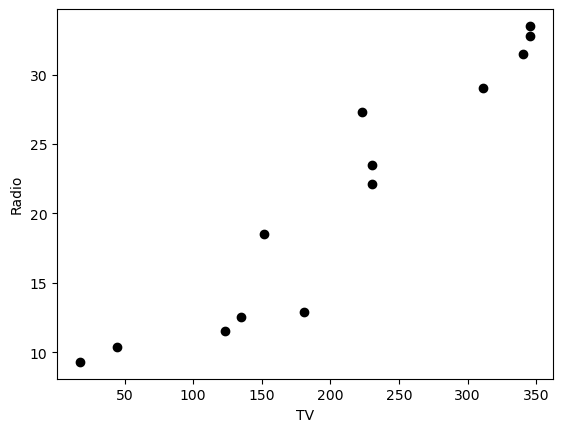

In [22]:
plt.scatter(x,y,c="black")
plt.xlabel('TV')
plt.ylabel('Radio')
plt.show()

In [23]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.1, random_state = 42)


In [24]:
x_train = s.add_constant(x_train)
x_test = s.add_constant(x_test)

In [25]:
model = s.OLS(y_train,x_train).fit()
model.summary()

c:\ProgramData\anaconda3\lib\site-packages\scipy\stats\_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=11
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     52.34
Date:                Tue, 29 Jul 2025   Prob (F-statistic):           4.90e-05
Time:                        08:57:14   Log-Likelihood:                -27.563
No. Observations:                  11   AIC:                             59.13
Df Residuals:                       9   BIC:                             59.92
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4595      2.111      2.586      0.029       0.684      10.235
TV             0.0747      0.010      7.234      0.000       0.051       0.098
==============================================================================
Omnibus:                        0.820   Durbin-Watson:                   2.107
Prob(Omnibus):                  0.664   Jarque-Bera (JB):                0.328
Skew:                          -0.403   Prob(JB):                        0.849
Kurtosis:                       2.744   Cond. No.                         437.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""